# ANLYSE PRICE AND ODOR



In [4]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [ ]:
import pandas as pd

#load of the dataset
data= pd.read_csv("../../Data/useCarData.csv", sep=";")
# Remove any Leading/trailing whitespace from column names
data.columns = data.columns.str.strip() 

# Variable price and odor
price= 'Price (EUR)'
odor= 'Odor'
print(odor)

print(price)
#data.isnull().sum()


Odor
Price (EUR)


Brand and model                          0
Year of manufacture                      0
Mileage                                  0
Engine power (hp)                        0
Fuel type                                0
Transmission type                        0
Trim level / Equipment line              0
Vehicle condition                        0
Origin                                   0
Energy consumption                       0
Power output (kW)                        0
Category / Vehicle type                  0
Engine displacement (cc)                 0
Price (EUR)                              0
Color                                    0
Air conditioning / Climate control       0
Transmission                             0
Number of doors                          0
Number of seats                          0
Drive type                               0
Interior equipment / Interior design     0
Accident history                         0
Number of previous owners                0
Maintenance

In [ ]:
oder_stats = data[odor].info()
print(oder_stats)

print('\n')
print(f'{odor} Value counts')
print('*'*50)
odor_counts=data[odor].value_counts()
print(odor_counts)



<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: Odor
Non-Null Count  Dtype 
--------------  ----- 
81 non-null     object
dtypes: object(1)
memory usage: 928.0+ bytes
None


Odor Value counts
**************************************************
Odor
Smoke       34
Pet odor    24
Moisture    23
Name: count, dtype: int64


## Plot a diagram 

(array([0, 1, 2]),
 [Text(0, 0, 'Smoke'), Text(1, 0, 'Pet odor'), Text(2, 0, 'Moisture')])

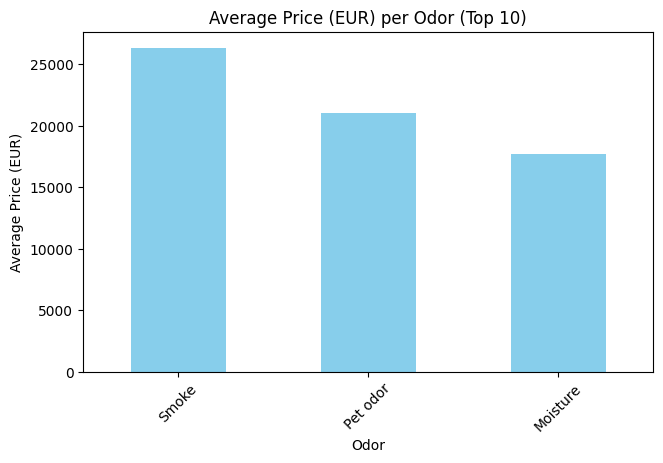

In [16]:
# Graphique 1: Prix par marque

plt.figure(figsize=(25,15))
plt.subplot(3, 3, 1)
brand_price = data.groupby(odor)[price].mean().sort_values(ascending=False)
brand_price.head(10).plot(kind='bar', color='skyblue')
plt.title(f'Average {price} per {odor} (Top 10)')
plt.xlabel(odor)
plt.ylabel(f'Average {price}')

plt.xticks(rotation=45)

# correlation diagram

Erklärung:

- data[['Price', 'Year']] wählt nur diese beiden Spalten aus.

- .corr() berechnet die Pearson-Korrelation.

- sns.heatmap zeigt die Korrelation grafisch an.

In [ ]:
# Graphique 2: Prix vs Année de fabrication


# Korrelation berechnen
# corr_value = data[[price, odor]].corr().iloc[0,1]
# print("Correlation between Price and Odor:", corr_value)

# plt.figure(figsize=(12,10))  # set the figure size

# plt.subplot(3, 3, 2)
# sns.heatmap(data[['Price', odor]].corr(), annot=True, cmap='coolwarm', fmt=".2f")

# plt.title('Relationship between Price vs Odor')
# plt.xlabel(odor)
# plt.ylabel('Prix (EUR)')
# plt.grid(True, alpha=0.3)

## Scatter plot

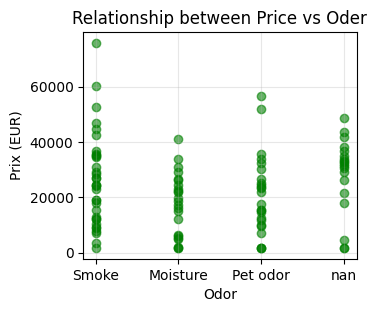

In [ ]:
# Graphique 2: Prix vs Année de fabrication
plt.figure(figsize=(12,10))  # set the figure size

plt.subplot(3, 3, 3)
plt.scatter(data[odor].astype(str), data[price], alpha=0.6, color='green')
plt.title(f'Relationship between {price} vs {odor}')
plt.xlabel(f'{odor}')
plt.ylabel(f'{price}')
plt.grid(True, alpha=0.3)

## Boxplot diagramm

([0, 1, 2],
 [Text(0, 0, 'Smoke'), Text(1, 0, 'Moisture'), Text(2, 0, 'Pet odor')])

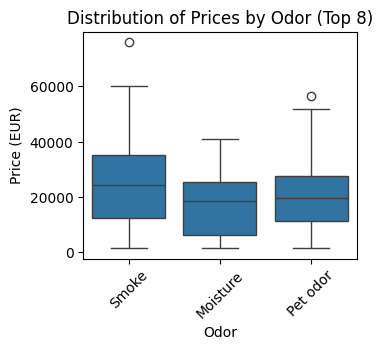

In [ ]:
# Graphique 3: Boxplot price per type of odor

plt.figure(figsize=(12,10))  # set the figure size

plt.subplot(3, 3, 4)
top_categories = data[odor].value_counts().head(8).index
filtered_df = data[data[odor].isin(top_categories)]
sns.boxplot(data=filtered_df, x=odor, y=price)
plt.title('Distribution of Prices by Odor (Top 8)')
plt.xticks(rotation=45)

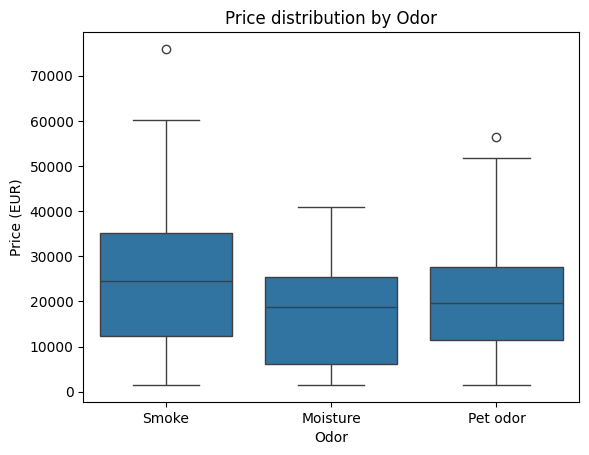

In [ ]:
data.groupby(odor)[price].mean().sort_values(ascending=False)
sns.boxplot(data=data, x=odor, y=price)
plt.title(f'{price} distribution by Odor')
plt.show()